<a href="https://colab.research.google.com/github/mgis8/Patch-based-detection-of-AI-generated-images/blob/main/ML_Final_Work_Patches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Imports:

In [1]:
pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=5c624bdb7e94ce4b3166385eeba2db8f13a1f1d18d857fa4bdacf6b23bd8e456
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [2]:
# General ML imports
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split

# NN imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Displaying images imports
import matplotlib.pyplot as plt

# Image parsing imports
from PIL import Image
from IPython.display import display

import random
import os
from collections import Counter
import time
import kagglehub

# Face recognition import for cropping faces
import face_recognition

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


###Load Data:

In [5]:
!unzip /content/real_images.zip -d /content/data/
!unzip /content/fake_images.zip -d /content/data/

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/fake/056278.jpg  
  inflating: /content/data/__MACOSX/fake/._056278.jpg  
  inflating: /content/data/fake/027481.jpg  
  inflating: /content/data/__MACOSX/fake/._027481.jpg  
  inflating: /content/data/fake/007751.jpg  
  inflating: /content/data/__MACOSX/fake/._007751.jpg  
  inflating: /content/data/fake/039867.jpg  
  inflating: /content/data/__MACOSX/fake/._039867.jpg  
  inflating: /content/data/fake/016884.jpg  
  inflating: /content/data/__MACOSX/fake/._016884.jpg  
  inflating: /content/data/fake/041704.jpg  
  inflating: /content/data/__MACOSX/fake/._041704.jpg  
  inflating: /content/data/fake/008304.jpg  
  inflating: /content/data/__MACOSX/fake/._008304.jpg  
  inflating: /content/data/fake/007037.jpg  
  inflating: /content/data/__MACOSX/fake/._007037.jpg  
  inflating: /content/data/fake/041062.jpg  
  inflating: /content/data/__MACOSX/fake/._041062.jpg  
  inflating: /content/data/fake/018117.j

In [6]:
paths  = [f'/content/data/real/{i:06d}.jpg' for i in range(69500)]
labels = [0] * 69500

paths  += [f'/content/data/fake/{i:06d}.jpg' for i in range(69500)]
labels += [1] * 69500

###Train, Validation, Test Split:

In [7]:
# First split: train vs (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Train split for 25% of total training sample models
X_25, _, y_25, _ = train_test_split(
    X_train, y_train,
    test_size=0.75,
    stratify=y_train,
    random_state=42
)

# Train split for 10% of total training sample models
X_10, _, y_10, _ = train_test_split(
    X_train, y_train,
    test_size=0.9,
    stratify=y_train,
    random_state=42
)

In [8]:
class GridPatchDataset(Dataset):
    def __init__(self, image_paths, labels, patch_size):
        self.paths      = image_paths
        self.labels     = labels
        self.patch_size = patch_size
        self.img_size   = 128
        self.grid       = self.img_size // patch_size

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

        self.index = [  # Index: indexs to the particular patch
            (img_idx, r, c)
            for img_idx in range(len(image_paths))
            for r in range(self.grid)
            for c in range(self.grid)
        ]

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        img_idx, r, c = self.index[idx]
        ps = self.patch_size

        img = Image.open(self.paths[img_idx]).convert('RGB')
        left, upper = c * ps, r * ps
        patch = img.crop((left, upper, left + ps, upper + ps))

        return self.transform(patch), self.labels[img_idx], img_idx

###Dataloader Initialization:

In [9]:
# Normal training size 16x16 model data loaders
batch_size = 1024
patch_size = 16

# Training Data
trainingData16 = GridPatchDataset(X_train, y_train, patch_size)
train_dataloader16 = DataLoader(trainingData16, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
valData16 = GridPatchDataset(X_val, y_val, patch_size)
val_dataloader16 = DataLoader(valData16, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
testData16 = GridPatchDataset(X_test, y_test, patch_size)
test_dataloader16 = DataLoader(testData16, batch_size=batch_size, shuffle=True, num_workers=8)

In [10]:
# Normal training size 16x16 model data loaders

batch_size = 256
patch_size = 32

# Training Data
trainingData32 = GridPatchDataset(X_train, y_train, patch_size)
train_dataloader32 = DataLoader(trainingData32, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
valData32 = GridPatchDataset(X_val, y_val, patch_size)
val_dataloader32 = DataLoader(valData32, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
testData32 = GridPatchDataset(X_test, y_test, patch_size)
test_dataloader32 = DataLoader(testData32, batch_size=batch_size, shuffle=True, num_workers=8)

In [11]:
# Normal training size 64x64 model data loaders

batch_size = 64
patch_size = 64

# Training Data
trainingData64 = GridPatchDataset(X_train, y_train, patch_size)
train_dataloader64 = DataLoader(trainingData64, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
valData64 = GridPatchDataset(X_val, y_val, patch_size)
val_dataloader64 = DataLoader(valData64, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
testData64 = GridPatchDataset(X_test, y_test, patch_size)
test_dataloader64 = DataLoader(testData64, batch_size=batch_size, shuffle=True, num_workers=8)

In [12]:
# Normal training size 128x128 model data loaders

batch_size = 16
patch_size = 128

# Training Data
trainingData128 = GridPatchDataset(X_train, y_train, patch_size)
train_dataloader128 = DataLoader(trainingData128, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
valData128 = GridPatchDataset(X_val, y_val, patch_size)
val_dataloader128 = DataLoader(valData128, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
testData128 = GridPatchDataset(X_test, y_test, patch_size)
test_dataloader128 = DataLoader(testData128, batch_size=batch_size, shuffle=True, num_workers=8)

In [13]:
# Data Loaders for 128x128 patch model limited to 25% of training data

batch_size = 16
patch_size = 128

# Training Data
training25Data128 = GridPatchDataset(X_25, y_25, patch_size)
train_data25loader128 = DataLoader(training25Data128, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
val25Data128 = GridPatchDataset(X_val, y_val, patch_size)
val_data25loader128 = DataLoader(val25Data128, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
test25Data128 = GridPatchDataset(X_test, y_test, patch_size)
test_data25loader128 = DataLoader(test25Data128, batch_size=batch_size, shuffle=True, num_workers=8)

In [14]:
# Data Loaders for 32x32 patch model limited to 25% of training data

batch_size = 256
patch_size = 32

# Training Data
training25Data32 = GridPatchDataset(X_25, y_25, patch_size)
train_data25loader32 = DataLoader(training25Data32, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
val25Data32 = GridPatchDataset(X_val, y_val, patch_size)
val_data25loader32 = DataLoader(val25Data32, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
test25Data32 = GridPatchDataset(X_test, y_test, patch_size)
test_data25loader32 = DataLoader(test25Data32, batch_size=batch_size, shuffle=True, num_workers=8)

In [15]:
# Data Loaders for 128x128 patch model limited to 10% of training data

batch_size = 16
patch_size = 128

# Training Data
training10Data128 = GridPatchDataset(X_10, y_10, patch_size)
train_data10loader128 = DataLoader(training10Data128, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
val10Data128 = GridPatchDataset(X_val, y_val, patch_size)
val_data10loader128 = DataLoader(val10Data128, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
test10Data128 = GridPatchDataset(X_test, y_test, patch_size)
test_data10loader128 = DataLoader(test10Data128, batch_size=batch_size, shuffle=True, num_workers=8)

In [16]:
# Data Loaders for 32x32 patch model limited to 10% of training data

batch_size = 256
patch_size = 32

# Training Data
training10Data32 = GridPatchDataset(X_10, y_10, patch_size)
train_data10loader32 = DataLoader(training10Data32, batch_size=batch_size, shuffle=True, num_workers=8)

# Validation Data
val10Data32 = GridPatchDataset(X_val, y_val, patch_size)
val_data10loader32 = DataLoader(val10Data32, batch_size=batch_size, shuffle=True, num_workers=8)

# Test Data
test10Data32 = GridPatchDataset(X_test, y_test, patch_size)
test_data10loader32 = DataLoader(test10Data32, batch_size=batch_size, shuffle=True, num_workers=8)

In [17]:
# Dataloaders, change depending on what size patch,
# we are training the model on.
currentPatchSize = 32
currentTrainDataLoader = train_data10loader32
currentValDataLoader = val_data10loader32
currentTestDataLoader = test_data10loader32

###**Naive Neural Network**:

*   Fully Connected layers implementation

In [18]:
class NaiveNeuralNetwork(nn.Module):
    def __init__(self):
        super(NaiveNeuralNetwork, self).__init__()
        #input size for RBG images is 32 * 32 * 3
        self.fc1 = nn.Linear(32 * 32 * 3, 64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,16)
        self.fc4 = nn.Linear(16,2) # output layer(binary classification)


    def forward(self, x):
       #flatten the image
       x = x.view(-1 , 32 * 32 * 3)
       #relu activation
       x = F.relu(self.fc1(x))
       x = F.relu(self.fc2(x))
       x = F.relu(self.fc3(x))
       x = self.fc4(x) #output
       return x

naive_model = NaiveNeuralNetwork().to(device)
naive_criterion = torch.nn.CrossEntropyLoss()
naive_optimizer = optim.Adam(naive_model.parameters(), lr=0.001)


start = time.time() # seconds since epoch

# Training loop
for epoch in range(1):
    naive_model.train()
    total_loss = 0
    num_batches = 0

    for batch in currentTrainDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)
        naive_optimizer.zero_grad()
        preds = naive_model(xTensor)
        loss = naive_criterion(preds, yTensor)
        loss.backward()
        naive_optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")



Epoch 1, Loss: 0.6936
Elapsed time: 15.27 seconds


### Naive NN Model Testing:

In [19]:
# Validation set accuracy:
naive_model.eval()

test_loss = 0
correct   = 0
num_batches = 0

with torch.no_grad():
    for batch in currentValDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = naive_model(xTensor)
        loss  = naive_criterion(preds, yTensor)
        test_loss  += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_val_loss = test_loss / num_batches
accuracy     = correct / len(currentValDataLoader.dataset)
print(f"Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}")

Val Loss: 0.6911, Accuracy: 0.5241


In [20]:
# Test accuracy
naive_model.eval() #set model to eval mode

test_loss   = 0
correct     = 0
num_batches = 0

with torch.no_grad():
    for batch in currentTestDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = naive_model(xTensor)
        loss  = naive_criterion(preds, yTensor)
        test_loss  += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_test_loss = test_loss / num_batches
accuracy      = correct / len(currentTestDataLoader.dataset)

print(f"Test Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}")

Test Loss: 0.6915, Accuracy: 0.5213


In [21]:
naive_model.eval() #set model to evaluation mode

test_loss   = 0
correct = 0
num_batches = 0

with torch.no_grad():
    for batch in currentTrainDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = naive_model(xTensor)
        loss  = naive_criterion(preds, yTensor)
        test_loss  += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_train_loss = test_loss / num_batches
accuracy       = correct / len(currentTrainDataLoader.dataset)
print(f"Train Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.4f}")

Train Loss: 0.6911, Accuracy: 0.5246


In [24]:
def getNaiveAggregatedAccuracy(): # Aggregated image-level accuracy
    num_images   = 0
    correctCount = 0

    for img_idx in range(len(X_test)):
        image   = Image.open(X_test[img_idx])
        patches = getTensorPatches(image)

        with torch.no_grad():
            preds            = naive_model(patches)
            predicted_labels = preds.argmax(dim=1)

        if sum(predicted_labels) >= len(predicted_labels) // 2:
            decisionClass = 1
        else:
            decisionClass = 0

        if decisionClass == y_test[img_idx]:
            correctCount += 1

        num_images += 1

    print(f"Total Correct: {correctCount} over {num_images} images")
    print(f"Accuracy {(correctCount / num_images) * 100:.2f}%")

getNaiveAggregatedAccuracy()

Total Correct: 7553 over 13900 images
Accuracy 54.34%


###**Convolutional Neural Network:**

In [ ]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, 1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [ ]:
model = ConvolutionalNeuralNetwork().to(device)
criterion = torch.nn.CrossEntropyLoss()  # Cross-Entropy Loss is standard for CNN
optimizer = optim.Adam(model.parameters(), lr=0.001) # Defaul LR for Adam optimizer is .001

###Model Training:

In [ ]:
start = time.time()  # seconds since epoch

for epoch in range(1): # Training Loop:
    model.train()
    total_loss = 0
    num_batches = 0

    for batch in currentTrainDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)
        optimizer.zero_grad()
        preds = model(xTensor)
        loss = criterion(preds, yTensor)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

end = time.time()
elapsed = end - start
print(f"Elapsed time: {elapsed:.2f} seconds")

Epoch 1, Loss: 0.4414
Elapsed time: 14.92 seconds


###Model Testing:

In [ ]:
# Test Model accuracy on validation set:
model.eval() # Set model to evaluation mode

test_loss = 0
correct = 0
num_batches = 0

with torch.no_grad():  # disable gradients for evaluation
    for batch in currentValDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = model(xTensor)
        loss = criterion(preds, yTensor)
        test_loss += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_test_loss = test_loss / num_batches
accuracy = correct / len(currentValDataLoader.dataset)

print(f"Val Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}")

Val Loss: 0.5069, Accuracy: 0.7491


In [ ]:
# To load models
model = ConvolutionalNeuralNetwork().to(device)
model.load_state_dict(torch.load("model32_23.pth"))

<All keys matched successfully>

In [ ]:
# Test Model accuracy on Test set:
model.eval() # Set model to evaluation mode

test_loss = 0
correct = 0
num_batches = 0

with torch.no_grad():  # disable gradients for evaluation
    for batch in currentTestDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = model(xTensor)
        loss = criterion(preds, yTensor)
        test_loss += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_test_loss = test_loss / num_batches
accuracy = correct / len(currentTestDataLoader.dataset)

print(f"Test Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}")

Test Loss: 0.5214, Accuracy: 0.7355


In [ ]:
# Test Model accuracy on Train set:
model.eval() # Set model to evaluation mode

test_loss = 0
correct = 0
num_batches = 0

with torch.no_grad():  # disable gradients for evaluation
    for batch in currentTrainDataLoader:
        xTensor = batch[0].to(device)
        yTensor = batch[1].to(device)

        preds = model(xTensor)
        loss = criterion(preds, yTensor)
        test_loss += loss.item()
        num_batches += 1

        predicted_labels = preds.argmax(dim=1)
        correct += (predicted_labels == yTensor).sum().item()

avg_test_loss = test_loss / num_batches
accuracy = correct / len(currentTrainDataLoader.dataset)

print(f"Train Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}")

Train Loss: 0.5022, Accuracy: 0.7482


###Data Visualization:

In [ ]:
def highlight(image, ps, probs):
    highlight_color_fake = (255, 80, 80)   # red
    highlight_color_real = (80, 255, 120)  # green`

    patchIdx = 0
    for i in range(ps, image.width+1, ps):
      for j in range(ps, image.height+1, ps):
        box = (i-ps, j-ps, i, j)
        region = image.crop(box)
        if probs[patchIdx][0] > probs[patchIdx][1]:
          highlight = Image.new(region.mode, region.size, highlight_color_real)
        else:
          highlight = Image.new(region.mode, region.size, highlight_color_fake)

        region = Image.blend(region, highlight, max(probs[patchIdx]))
        image.paste(region, box)
        patchIdx += 1

    display(image)

In [23]:
def getPatches(image, ps):
    retPatchArr = []
    for i in range(0, image.width, ps):
        for j in range(0, image.height, ps):
            box = (i, j, i + ps, j + ps)
            patch = image.crop(box)
            retPatchArr.append(np.array(patch, dtype=np.float32))
    return np.array(retPatchArr) / 255 # Normalize


def getTensorPatches(image):
  transform = transforms.Compose([
              transforms.ToTensor()
          ])

  patches = getPatches(image, currentPatchSize)
  patches = [transform(p).to(device) for p in patches]
  patches = torch.stack(patches)

  return patches


In [ ]:
def getAggregatedAccuracy(): # Accuracy based on all patches of an image
    num_images = 0
    correctCount = 0

    for img_idx in range(len(X_test)):
        image = X_test[img_idx]
        image = Image.open(image)
        patches = getTensorPatches(image)

        with torch.no_grad():  # disable gradients for evaluation
          preds = model(patches)
          predicted_labels = preds.argmax(dim=1)

        # Aggregate simply on higher proportion of patch labels
        if sum(predicted_labels) >= len(predicted_labels) // 2:
          decisionClass = 1
        else: decisionClass = 0

        trueLabel = y_test[img_idx]
        if decisionClass == trueLabel:
          correctCount += 1

        num_images += 1

    print(f"Total Correct: {correctCount} over {num_images} images")
    print(f"Accuracy {(correctCount / num_images) * 100:.2f}%")

getAggregatedAccuracy()


Total Correct: 11957 over 13900 images
Accuracy 86.02%


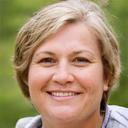

In [ ]:
from PIL import Image
import numpy as np
from IPython.display import display

# load image
image = Image.open("testPhoto.jpg")

# get patches
ps = 128
patches = getPatches(image, ps)

# convert patch back to image
patch_img = (patches[0] * 255).astype(np.uint8)  # undo normalization
patch_img = Image.fromarray(patch_img)

display(patch_img)

16x16 Model

True label: 0
Pred. label: 0


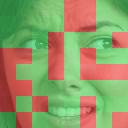

True label: 1
Pred. label: 1


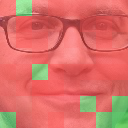

In [ ]:
# Red is estimated as AI generated
# Green is estimated as real
# Darker is higher estimated probability
def getProbHeatMap(testImageIdx):
  image = X_test[testImageIdx]
  image = Image.open(image)
  patches = getTensorPatches(image)

  trueLabel = y_test[testImageIdx]

  logits = []
  model.eval()
  with torch.no_grad(): # disable gradients for evaluation
      pred = model(patches)
      logits.append(pred)

  logits_tensor = torch.cat(logits, dim=0)

  temperature = 5 # Temperature scaling
  probs = F.softmax(logits_tensor / temperature, dim=1)
  probs_list = probs.tolist()

  decisions = logits_tensor.argmax(dim=1)
  if sum(decisions) >= len(decisions) // 2:
    decisionClass = 1
  else: decisionClass = 0


  print(f"True label: {trueLabel}")
  print(f"Pred. label: {decisionClass}")

  highlight(image, currentPatchSize, probs_list)

print("16x16 Model")
print()
getProbHeatMap(2004)
getProbHeatMap(1774)

###Saving and Loading Model:

In [ ]:
torch.save(model.state_dict(), "model32_23.pth") # Save model